<a href="https://colab.research.google.com/github/balajirj22-bit/CODSOFT-task-1/blob/main/Movie_Rating_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
from google.colab import files

uploaded = files.upload()

Saving IMDb Movies India.csv to IMDb Movies India.csv


In [5]:
import pandas as pd

df = pd.read_csv("IMDb Movies India.csv", encoding="latin-1")

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [7]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin-1")

In [8]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Genre"] = le.fit_transform(df["Genre"])
df["Director"] = le.fit_transform(df["Director"])
df["Actor 1"] = le.fit_transform(df["Actor 1"])
df["Actor 2"] = le.fit_transform(df["Actor 2"])
df["Actor 3"] = le.fit_transform(df["Actor 3"])

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,299,NaN,NaN,1926,2250,800,3108
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,299,7.0,8,1548,3280,4790,527
2,#Homecoming,(2021),90 min,351,NaN,NaN,5123,3713,2866,3450
3,#Yaaram,(2019),110 min,228,4.4,35,3319,2917,1504,4020
4,...And Once Again,(2010),105 min,299,NaN,NaN,385,3112,3462,405


In [10]:
X = df[["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]]
y = df["Rating"]

In [13]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df = df.dropna(subset=["Rating"])

df["Rating"].isnull().sum()

np.int64(0)

In [14]:
X = df[["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]]
y = df["Rating"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
df["Rating"].head(10)

,Rating
1,7.0
3,4.4
5,4.7
6,7.4
8,5.6
9,4.0
10,6.2
11,5.9
12,6.5
13,5.7


In [16]:
df["Rating"].dtype

dtype('float64')

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [20]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[5.256 5.558 5.437 6.349 4.488 6.168 5.983 6.405 6.139 6.005]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 1.0249724642255893
Root Mean Squared Error: 1.2876212040112829
R² Score: 0.1082092899715954


In [22]:
result = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": y_pred
})

result.head(10)

,Actual Rating,Predicted Rating
0,3.3,5.256
1,5.3,5.558
2,5.7,5.437
3,7.2,6.349
4,3.5,4.488
5,7.2,6.168
6,3.8,5.983
7,6.9,6.405
8,5.2,6.139
9,7.4,6.005


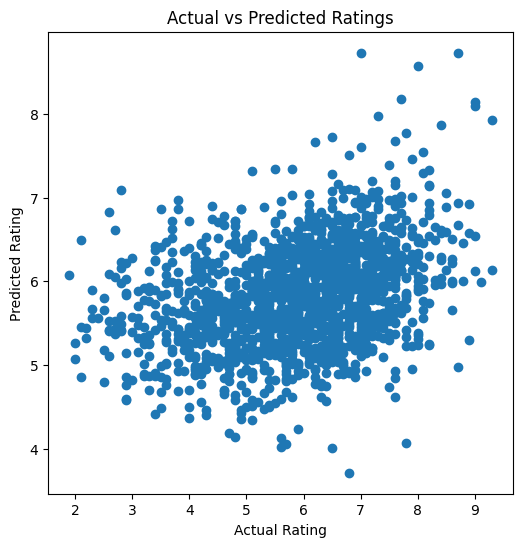

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()